## Step 1: Import Libraries & Setup

In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.1 MB/s eta 0:00:44
    --------------------------------------- 0.8/48.9 MB 1.2 MB/s eta 0:00:39
    --------------------------------------- 1.0/48.9 MB 1.3 MB/s eta 0:00:37
   - -------------------------------------- 1.6/48.9 MB 1.4 MB/s eta 0:00:34
   - -------------------------------------- 1.8/48.9 MB 1.5 MB/s eta 0:00:32
   - -------------------------------------- 2.4/48.9 MB 1.6 MB/s eta 0:00:30
   -- ------------------------------------- 2.9/48.9 MB 1.7 MB/s eta 0:00:28
   -- ------------------------------------- 3.4/48.9 MB 1.8 MB/s eta 0:00:26
   --- ------------------------------------ 3.9/48.9 MB 1.9 MB/s eta 0:00:25
   --- ------------------------------------ 4.7/48.9 MB 2.0 MB/s eta 0:00:23
   ---- ------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, precision_recall_curve)

# Imbalance handling
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

## Step 2: Load Dataset

In [5]:
df = pd.read_csv('Churn_Modelling.csv')

print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


## Step 3: EDA - Missing Values & Duplicates

In [8]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate CustomerId:", df['CustomerId'].duplicated().sum())

Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0
Duplicate CustomerId: 0


## Step 4: Tareget Variable Distribution

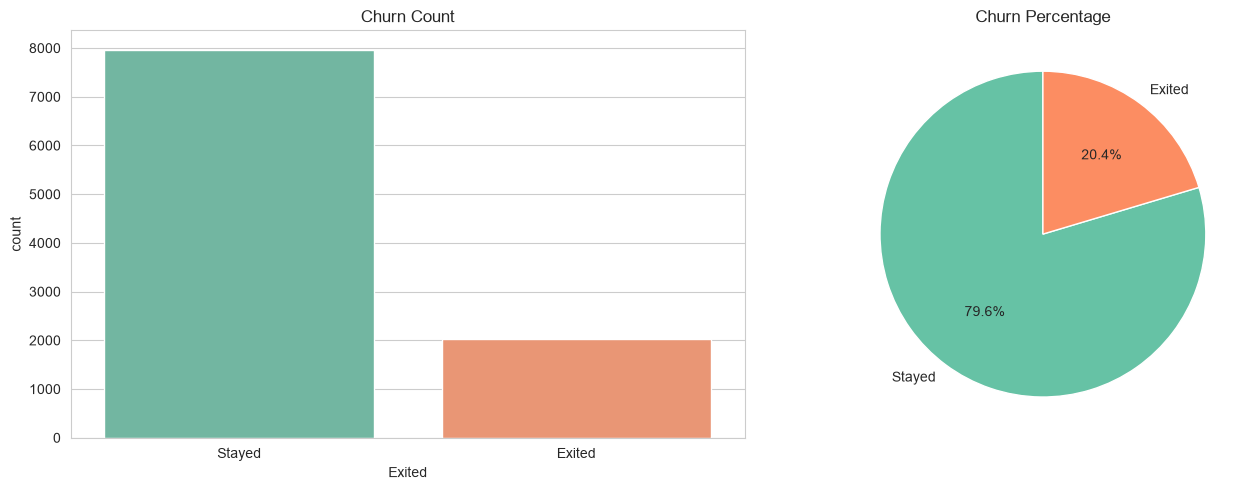

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [9]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Exited', data=df, ax=ax[0], palette='Set2')
ax[0].set_title('Churn Count')
ax[0].set_xticklabels(['Stayed', 'Exited'])

ax[1].pie(churn_counts, labels=['Stayed', 'Exited'], autopct='%1.1f%%',
          colors=sns.color_palette('Set2'), startangle=90)
ax[1].set_title('Churn Percentage')
plt.tight_layout()
plt.show()

print(churn_pct)

## Step 5: EDA - Categoraical Features vs Churn

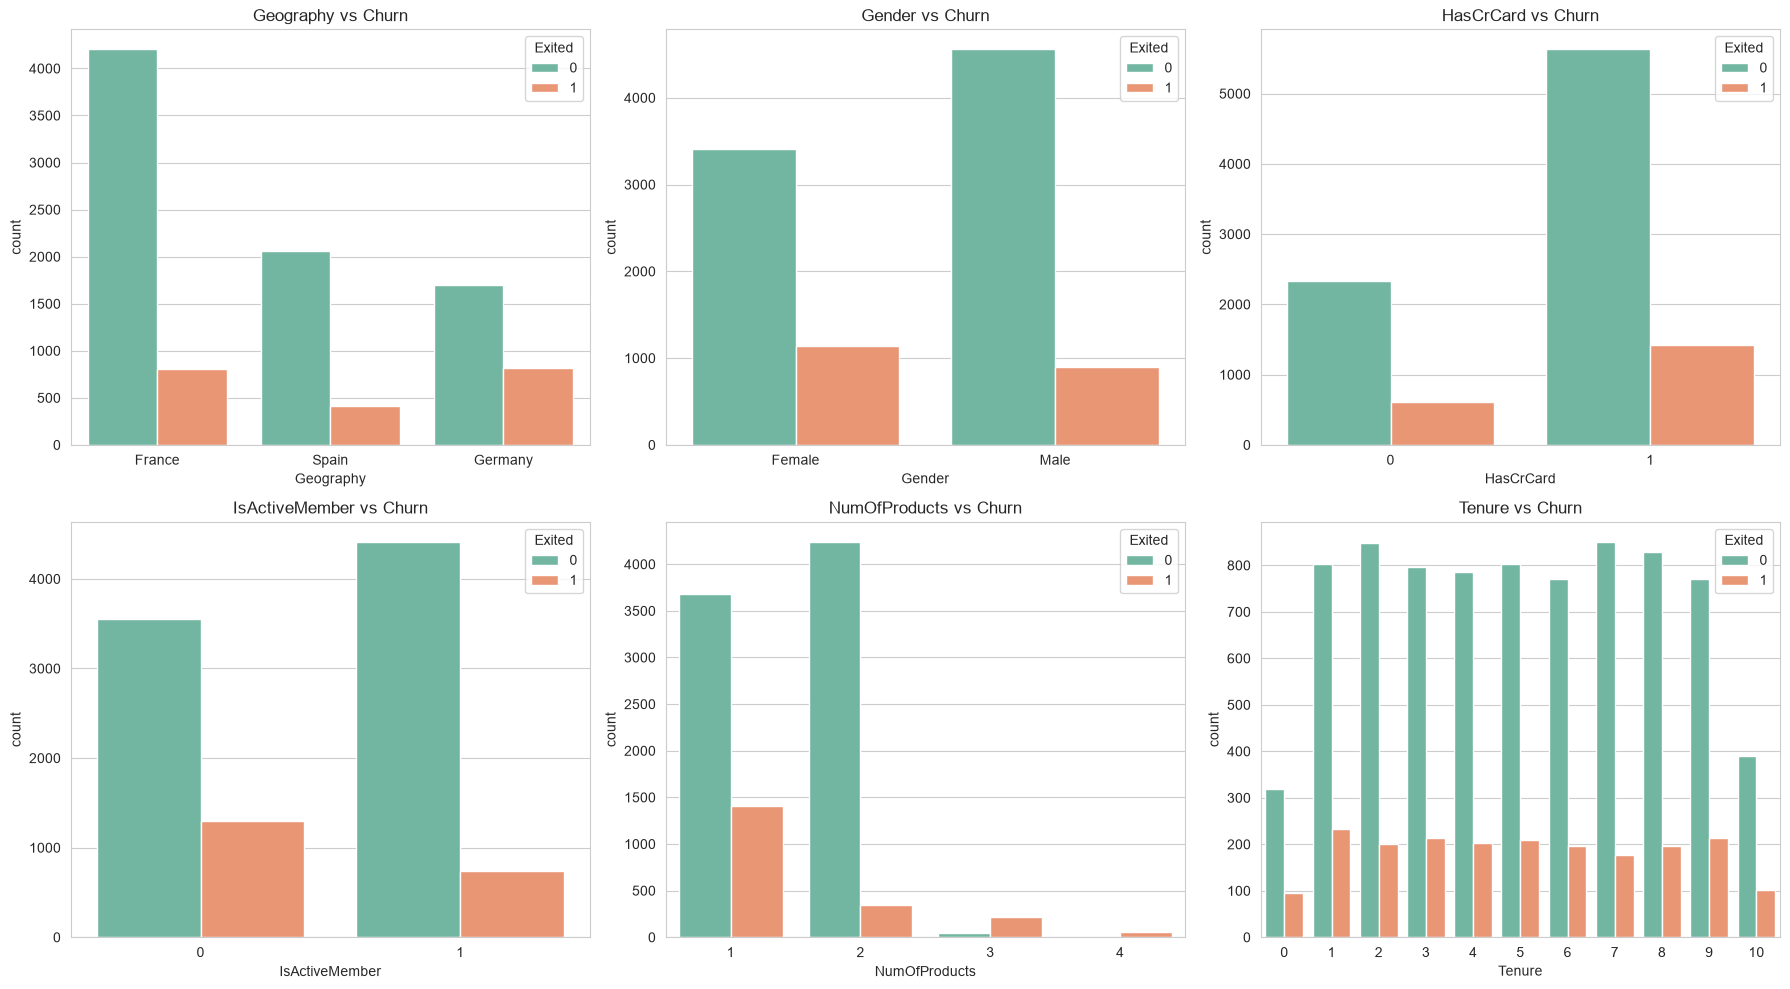

In [10]:
cat_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'Tenure']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='Exited', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

In [11]:
# Churn rate by Geography and Gender
for col in ['Geography', 'Gender']:
    print(f"\nChurn rate by {col}:")
    print(df.groupby(col)['Exited'].mean().sort_values(ascending=False))


Churn rate by Geography:
Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64

Churn rate by Gender:
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


## Step 6: EDA - Numeric Features vs Churn

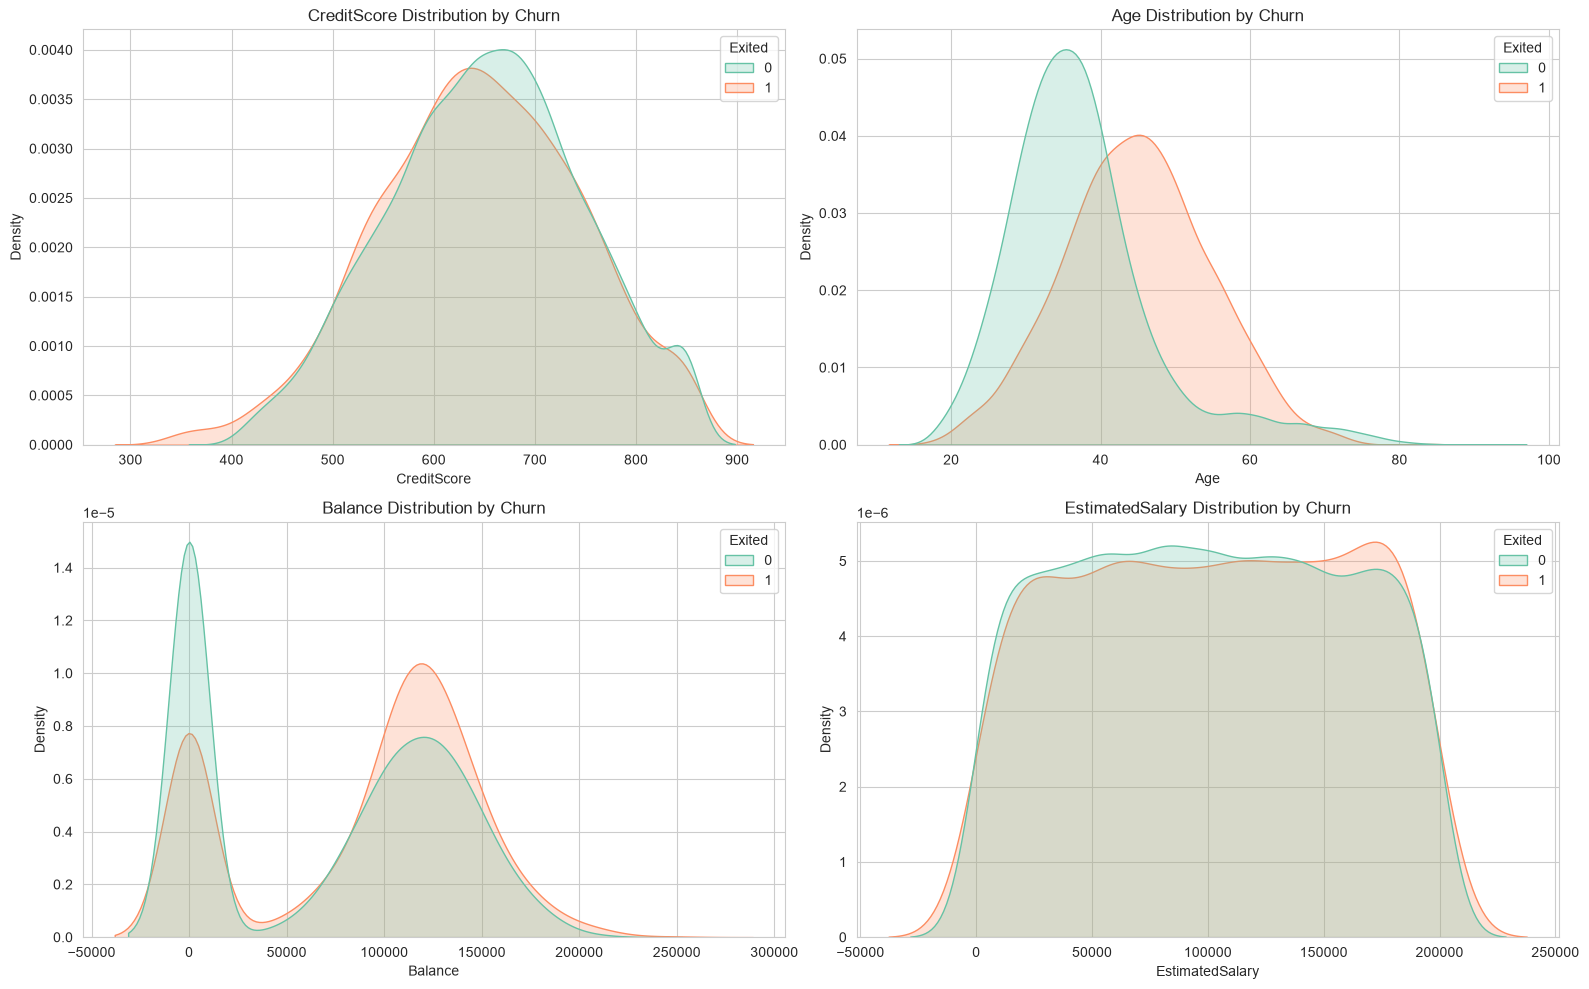

In [12]:
num_features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.kdeplot(data=df, x=col, hue='Exited', ax=axes[i], fill=True, common_norm=False, palette='Set2')
    axes[i].set_title(f'{col} Distribution by Churn')

plt.tight_layout()
plt.show()

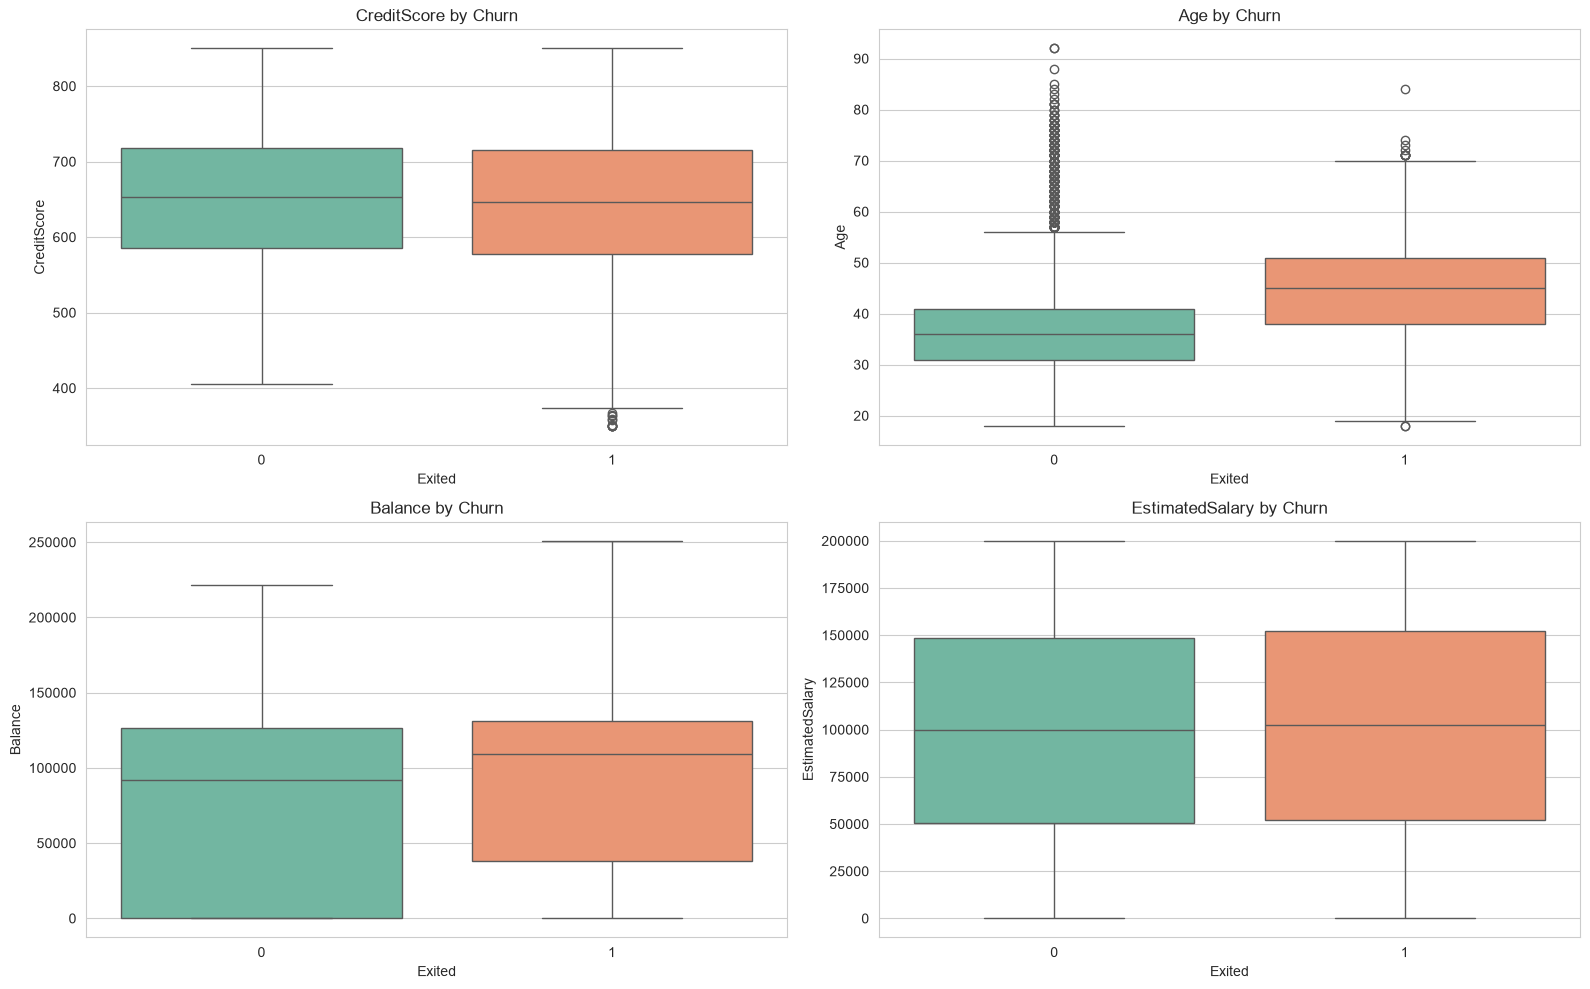

In [13]:
# Boxplots to spot outliers
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(x='Exited', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

## Step 7 : EDA - Correlation Heatmap

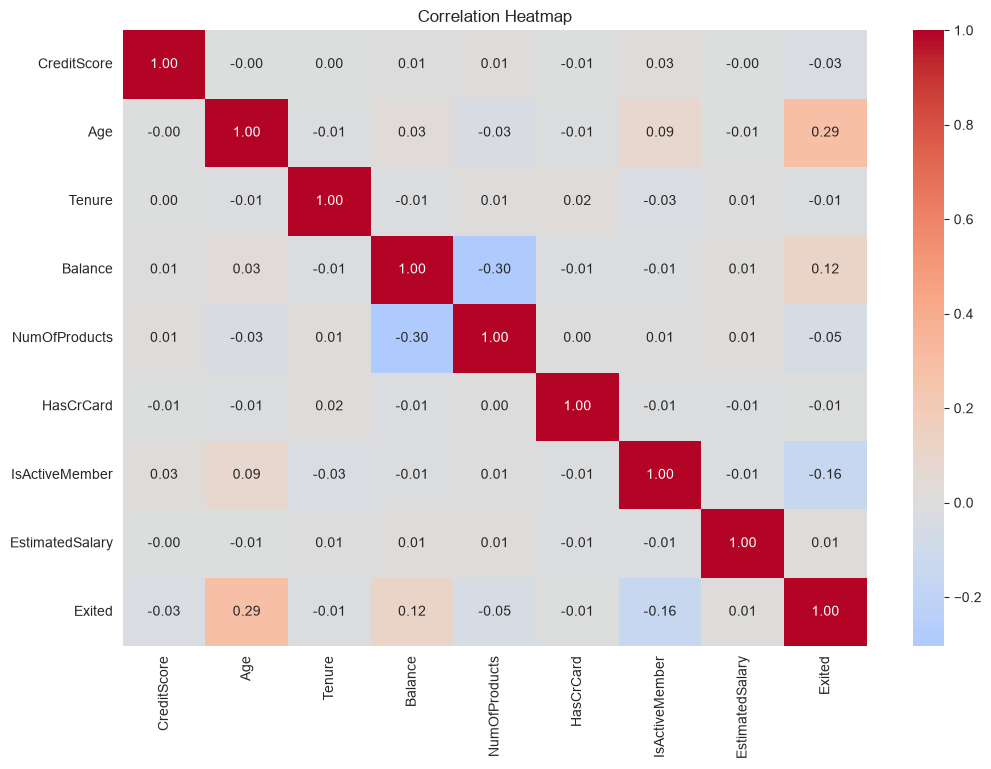

In [14]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['RowNumber', 'CustomerId'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## Step 8: Data Cleaning

In [15]:
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(df_clean.shape)
df_clean.head()

(10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 9: Feature Engineering

In [16]:
df_fe = df_clean.copy()

# 1. Balance to Salary ratio
df_fe['BalanceSalaryRatio'] = df_fe['Balance'] / (df_fe['EstimatedSalary'] + 1)

# 2. Age bins
df_fe['AgeGroup'] = pd.cut(df_fe['Age'], bins=[17, 30, 40, 50, 60, 100],
                            labels=['18-30', '31-40', '41-50', '51-60', '60+'])

# 3. Zero balance flag (many customers have 0 balance)
df_fe['IsZeroBalance'] = (df_fe['Balance'] == 0).astype(int)

# 4. Credit Score bins
df_fe['CreditScoreBucket'] = pd.cut(df_fe['CreditScore'], bins=[300, 580, 670, 740, 800, 900],
                                     labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Excellent'])

# 5. Products per tenure (engagement intensity)
df_fe['ProductsPerTenure'] = df_fe['NumOfProducts'] / (df_fe['Tenure'] + 1)

# 6. Tenure to Age ratio (how long as customer relative to their age)
df_fe['TenureAgeRatio'] = df_fe['Tenure'] / df_fe['Age']

# 7. Interaction: Active member with high balance = engaged; inactive with balance = churn risk
df_fe['ActiveWithBalance'] = ((df_fe['IsActiveMember'] == 1) & (df_fe['Balance'] > 0)).astype(int)

# 8. Estimated salary per credit score (financial health proxy)
df_fe['SalaryPerCreditScore'] = df_fe['EstimatedSalary'] / df_fe['CreditScore']

print(df_fe.shape)
df_fe.head()

(10000, 19)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,AgeGroup,IsZeroBalance,CreditScoreBucket,ProductsPerTenure,TenureAgeRatio,ActiveWithBalance,SalaryPerCreditScore
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,41-50,1,Fair,0.333333,0.047619,0,163.730016
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,41-50,0,Fair,0.500000,0.024390,1,185.102928
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,41-50,0,Poor,0.333333,0.190476,0,226.955319
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,31-40,1,Good,1.000000,0.025641,0,134.229800
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,41-50,0,Excellent,0.333333,0.046512,1,93.040118


## Step 10: Encoding Categorical Variables

In [17]:
df_encoded = df_fe.copy()

# One-hot encode nominal categoricals
df_encoded = pd.get_dummies(df_encoded, columns=['Geography', 'Gender', 'AgeGroup', 'CreditScoreBucket'],
                             drop_first=True)

print(df_encoded.shape)
df_encoded.columns.tolist()

(10000, 26)


['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'BalanceSalaryRatio',
 'IsZeroBalance',
 'ProductsPerTenure',
 'TenureAgeRatio',
 'ActiveWithBalance',
 'SalaryPerCreditScore',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Male',
 'AgeGroup_31-40',
 'AgeGroup_41-50',
 'AgeGroup_51-60',
 'AgeGroup_60+',
 'CreditScoreBucket_Fair',
 'CreditScoreBucket_Good',
 'CreditScoreBucket_VeryGood',
 'CreditScoreBucket_Excellent']

## Step 11: Train-Test Split

In [18]:
X = df_encoded.drop(columns=['Exited'])
y = df_encoded['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean(), "| Test churn rate:", y_test.mean())

Train shape: (8000, 25) Test shape: (2000, 25)
Train churn rate: 0.20375 | Test churn rate: 0.2035


## Step 12: Feature Scaling

In [19]:
scaler = StandardScaler()

num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary',
            'BalanceSalaryRatio', 'ProductsPerTenure', 'TenureAgeRatio', 'SalaryPerCreditScore']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## Step 13: Handle Class Imbalance with SMOTE

In [20]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 6370, 1: 1630}
After SMOTE: {1: 6370, 0: 6370}


## Step 14: Model 1 - Logistic Regression (Baseline)

In [21]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_bal, y_train_bal)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1593
           1       0.43      0.62      0.51       407

    accuracy                           0.75      2000
   macro avg       0.66      0.71      0.67      2000
weighted avg       0.80      0.75      0.77      2000

ROC-AUC: 0.7660032914270203


## Step 15: Model 2 - Random Forest

In [22]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_split=5,
    min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000

ROC-AUC: 0.8518641908472417


## Step 16: Model 3 - XGBoost (with GridSearch tuning)

In [23]:
xgb_params = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)

grid_search = GridSearchCV(
    xgb_base, xgb_params, cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc', n_jobs=-1, verbose=1
)

grid_search.fit(X_train_bal, y_train_bal)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

xgb_best = grid_search.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)
y_proba_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

print("\n=== XGBoost (Tuned) ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.9683772663756963

=== XGBoost (Tuned) ===
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      1593
           1       0.65      0.52      0.58       407

    accuracy                           0.85      2000
   macro avg       0.77      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000

ROC-AUC: 0.8296786771363042


## Step 17: Model Comparison

In [24]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})

print(results.sort_values('ROC-AUC', ascending=False).to_string(index=False))

              Model  Accuracy  Precision   Recall       F1  ROC-AUC
      Random Forest    0.8305   0.571730 0.665848 0.615210 0.851864
            XGBoost    0.8460   0.654206 0.515971 0.576923 0.829679
Logistic Regression    0.7545   0.429054 0.624079 0.508509 0.766003


## Step 18: ROC Curve Comparison

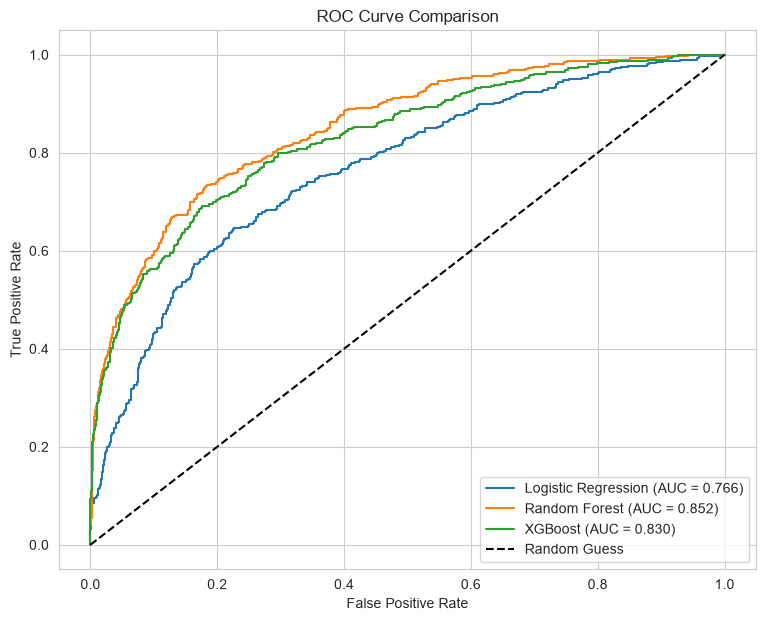

In [25]:
plt.figure(figsize=(9, 7))

for name, y_proba in [('Logistic Regression', y_proba_lr),
                       ('Random Forest', y_proba_rf),
                       ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## Step 19: Confusion Matrices

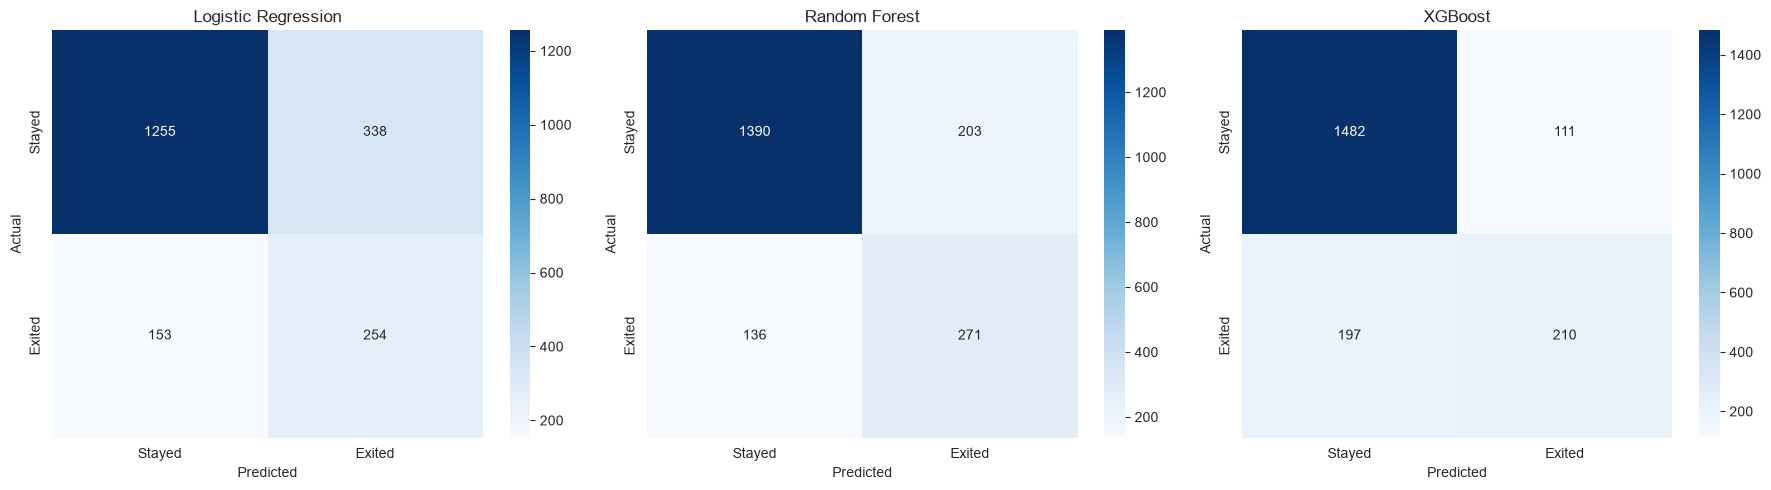

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                      ('Random Forest', y_pred_rf),
                                      ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Exited'], yticklabels=['Stayed', 'Exited'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 20: Feature Importance (XGBoost-best model)

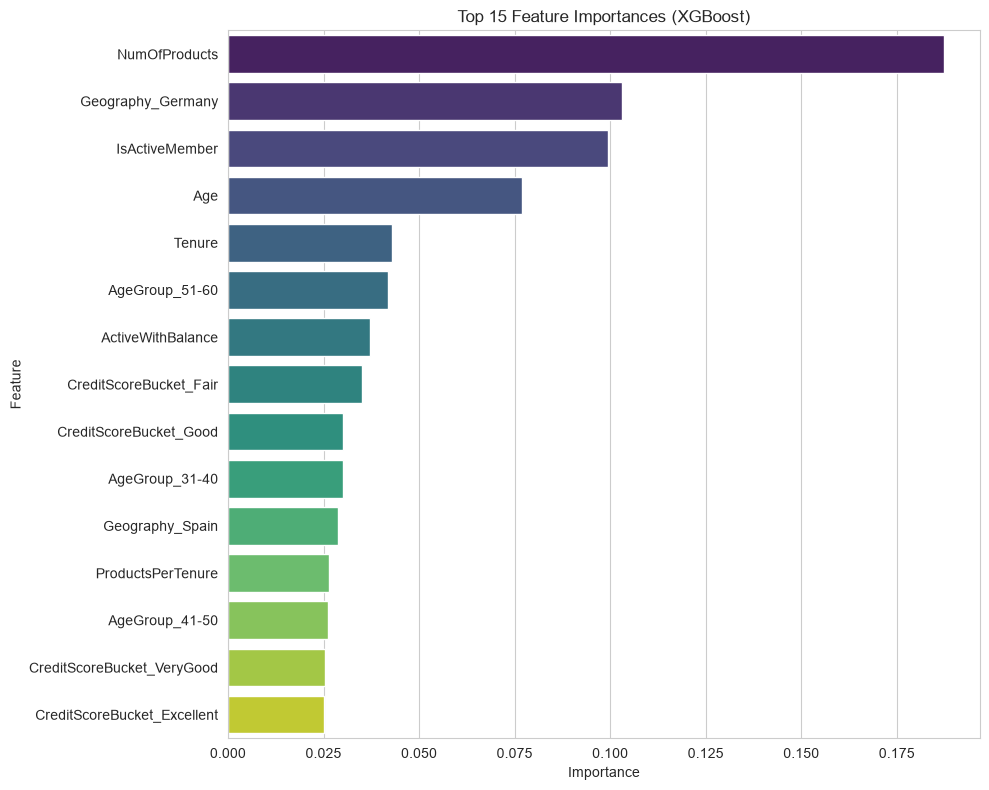

                        Feature  Importance
4                 NumOfProducts    0.187386
14            Geography_Germany    0.103008
6                IsActiveMember    0.099447
1                           Age    0.076972
2                        Tenure    0.042937
19               AgeGroup_51-60    0.041760
12            ActiveWithBalance    0.037187
21       CreditScoreBucket_Fair    0.035054
22       CreditScoreBucket_Good    0.030140
17               AgeGroup_31-40    0.029987
15              Geography_Spain    0.028826
10            ProductsPerTenure    0.026386
18               AgeGroup_41-50    0.026089
23   CreditScoreBucket_VeryGood    0.025280
24  CreditScoreBucket_Excellent    0.025132


In [27]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importances.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

print(importances.head(15))

## Step 21: SHAP Explainability (Advanced-makes the project stand out)

In [29]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



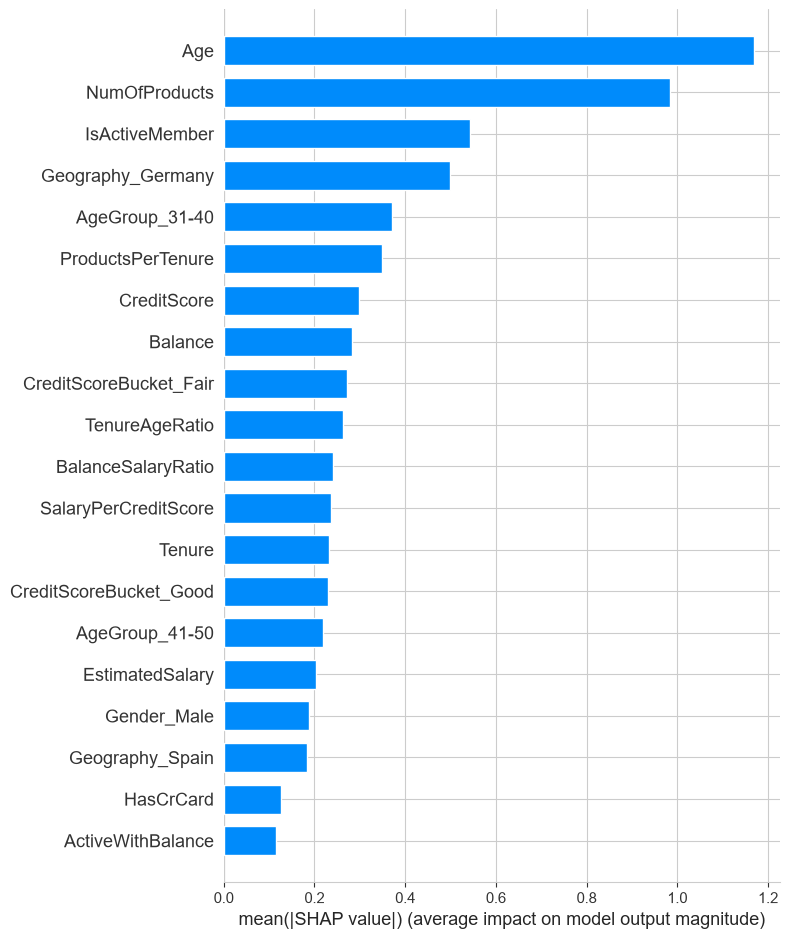

In [30]:
import shap

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot - overall feature impact
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=True)

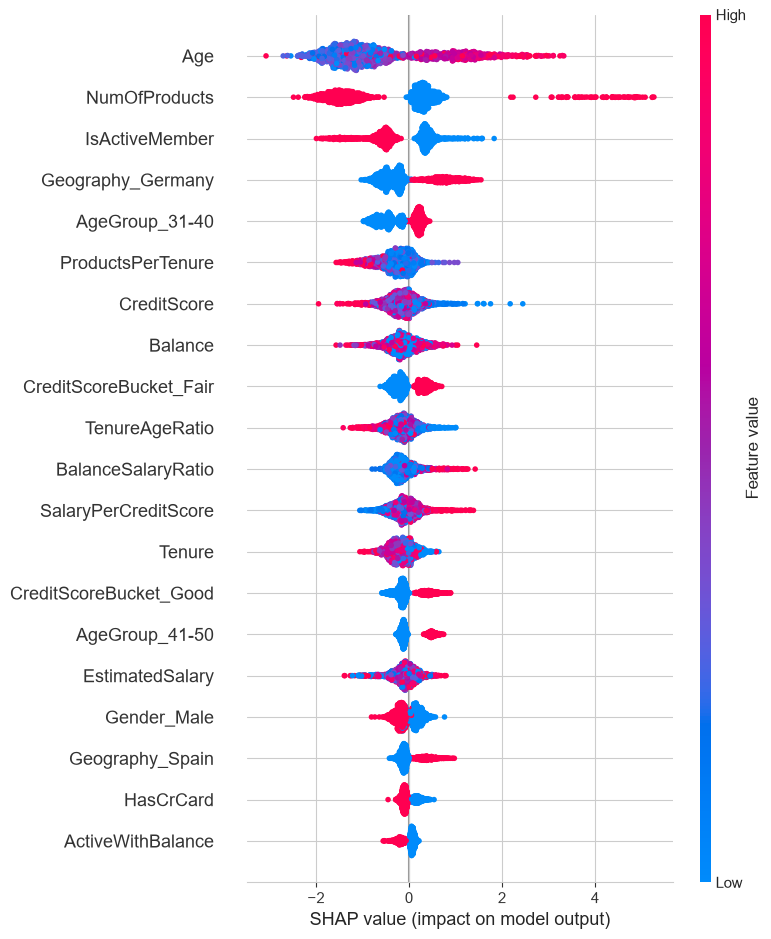

In [31]:
# Detailed impact direction (does the feature push toward or away from churn)
shap.summary_plot(shap_values, X_test_scaled, show=True)

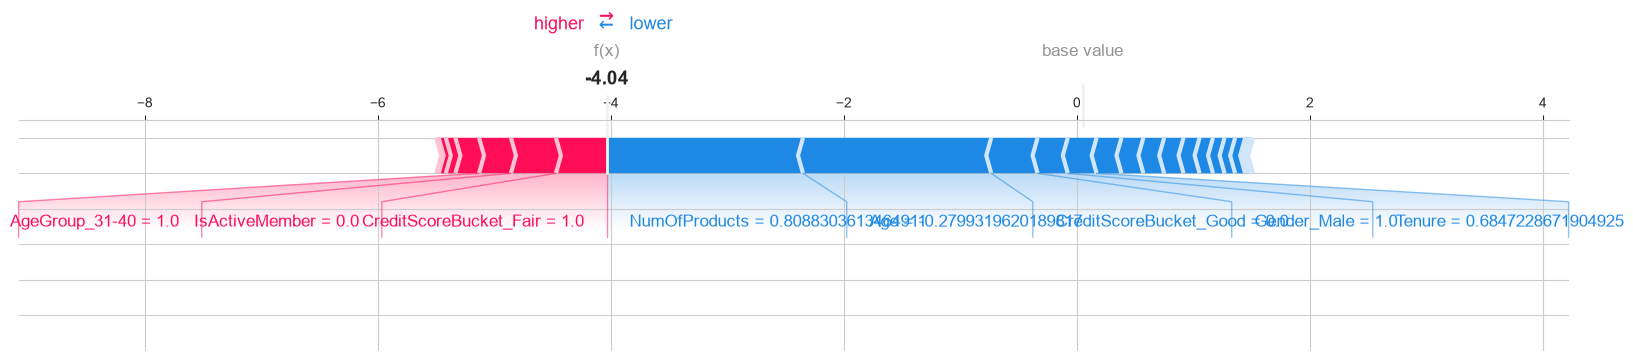

In [32]:
# Explain a single prediction (e.g. first test customer)
shap.force_plot(explainer.expected_value, shap_values[0], X_test_scaled.iloc[0],
                 matplotlib=True, show=True)

## Step 22: Threshold Tuning (business-focused, optional but strong addition)

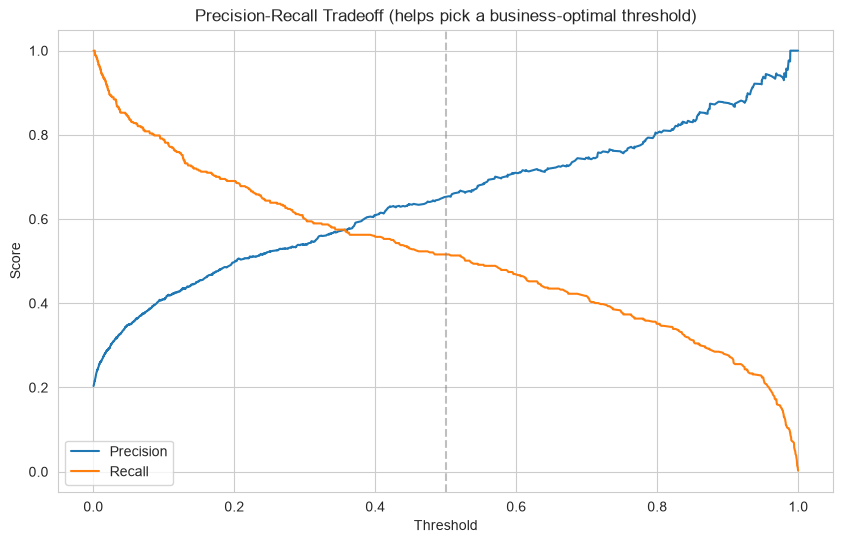

Best threshold for max F1: 0.421


In [33]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff (helps pick a business-optimal threshold)')
plt.legend()
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
plt.show()

# Example: choose threshold that maximizes F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold for max F1: {best_threshold:.3f}")

## Step 23: Save the Final Model

In [34]:
import joblib

joblib.dump(xgb_best, 'churn_model_xgboost.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.
